<a href="https://colab.research.google.com/github/weronikadomczewska/Uczenie-Glebokie-P/blob/main/corrected_resnet_cifar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## First step of the project

Training Resnet18 on CIFAR10 dataset (expected accuracy 90%)

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import random_split, DataLoader

try:
  from torchinfo import summary
except:
  !pip install torchinfo
  from torchinfo import summary

import torchvision
from torchvision import datasets
from torchvision import transforms
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sn
import numpy as np
import random
from typing import List , Dict , Tuple

## Training device setup

In [ ]:
# set device
device = torch.device('cuda')
print(device)

cuda


## Resnet implementation

In [ ]:
import torch.nn as nn

class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out = out + self.shortcut(identity)
        out = self.relu(out)
        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=10, encoder=None):
        super().__init__()
        self.initial_conv = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(64, 64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        layers.append(BasicBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn(self.initial_conv(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

## Data augmentations - the same ones as in SimCRL
## Dataset preparation: split into train (70%), test (20%), val (10%)

In [ ]:
from torchvision import transforms
import random
from PIL import ImageFilter
from torch.utils.data import random_split

# # Mean i std ImageNet (na nich bazuje większość eksperymentów SimCLR)
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]


# Własna implementacja Gaussian Blur (SimCLR używa zmiennego sigma)
class GaussianBlur:
    """Apply Gaussian Blur with random sigma"""
    def __init__(self, p=0.5, sigma_min=0.1, sigma_max=2.0):
        self.p = p
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max

    def __call__(self, img):
        if random.random() < self.p:
            sigma = random.uniform(self.sigma_min, self.sigma_max)
            return img.filter(ImageFilter.GaussianBlur(radius=sigma))
        return img

# simclr_transform = transforms.Compose([
#     transforms.RandomResizedCrop(size=32, scale=(0.08, 1.0), ratio=(0.75, 1.333)),
#     transforms.RandomHorizontalFlip(p=0.5),

#     # (jitter: jasność, kontrast, nasycenie, odcień)
#     transforms.RandomApply(
#         [transforms.ColorJitter(0.8, 0.8, 0.8, 0.2)],
#         p=0.8
#     ),

#     transforms.RandomGrayscale(p=0.2),
#     GaussianBlur(p=0.5),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=mean, std=std),
# ])

# best augmentations

# simclr_transform = transforms.Compose([
#     # Flip the images randomly on the horizontal
#     transforms.RandomHorizontalFlip(p=0.5),
#     # Randomly rotate some images by 20 degrees
#     transforms.RandomRotation(20),
#     # Randomly adjust color jitter of the images
#     transforms.ColorJitter(brightness=0.1,contrast=0.1,saturation=0.1),
#     # Randomly adjust sharpness
#     transforms.RandomAdjustSharpness(sharpness_factor=2,p = 0.2),
#     # Turn the image into a torch.Tensor
#     transforms.ToTensor() ,
#     #randomly erase a pixel
#     transforms.Normalize(mean, std),
#     transforms.RandomErasing(p=0.75,scale=(0.02, 0.1),value=1.0, inplace=False)

# ])

# simcrl augmentations
simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

full_train_data = datasets.CIFAR10(root="./data", train=True, download=True, transform=simclr_transform)
val_size = int(0.1 * len(full_train_data))  # 10% for validation
train_size = len(full_train_data) - val_size
train_data, val_data = random_split(full_train_data, [train_size, val_size])

batch_size = 128

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

test_data = datasets.CIFAR10(root="./data", train=False, download=True, transform=simclr_transform)
test_loader = DataLoader(test_data, batch_size=100, shuffle=False, num_workers=2, pin_memory=True)

def validate(model, val_loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

    val_loss = total_loss / len(val_loader)
    val_acc = correct / len(val_loader.dataset)
    return val_loss, val_acc

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18
from tqdm import tqdm

model = ResNet18()

device = torch.device("cuda")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
#SGD - za słabe accuracy
optimizer = torch.optim.Adam(model.parameters(),lr=0.001,weight_decay=35e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer,mode='min',factor=0.3,patience=3,threshold=0.09)
# optimizer = torch.optim.SGD(model.parameters(), lr=0.001,momentum=0.9,weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# Add structure to save metrics
train_losses, val_losses, test_losses = [], [], []
train_accuracies, val_accuracies, test_accuracies = [], [], []

def train_model(model, train_loader, val_loader, test_loader, epochs=50):
    best_accuracy = 0.0
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

        train_loss = total_loss / len(train_loader)
        train_acc = correct / len(train_loader.dataset)

        model.eval()
        total_loss, correct = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()

        val_loss = total_loss / len(val_loader)
        val_acc = correct / len(val_loader.dataset)

        # Test loop
        total_loss, correct = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()

        test_loss = total_loss / len(test_loader)
        test_acc = correct / len(test_loader.dataset)

        # Save metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        test_accuracies.append(test_acc)

        # Step scheduler
        scheduler.step(val_loss)

        # Save best weights (based on validation accuracy)
        if val_acc > best_accuracy:
            best_accuracy = val_acc
            torch.save(model.state_dict(), "best_resnet18_cifar10.pth")

        # Print epoch summary
        print(f"Epoch [{epoch+1}/{epochs}] - "
              f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}, "
              f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Test Loss: {test_loss:.4f}")

    # Save final weights after training completes
    torch.save(model.state_dict(), "final_resnet18_cifar10.pth")

train_model(model, train_loader, val_loader, test_loader)

Epoch [1/50] - Train Acc: 0.3358, Val Acc: 0.4150, Test Acc: 0.4215, Train Loss: 1.8151, Val Loss: 1.6532, Test Loss: 1.6113


Epoch [2/50] - Train Acc: 0.4885, Val Acc: 0.3706, Test Acc: 0.3599, Train Loss: 1.4257, Val Loss: 1.9555, Test Loss: 1.9427


Epoch [3/50] - Train Acc: 0.5629, Val Acc: 0.5648, Test Acc: 0.5595, Train Loss: 1.2374, Val Loss: 1.2367, Test Loss: 1.2396


Epoch [4/50] - Train Acc: 0.6085, Val Acc: 0.5392, Test Acc: 0.5419, Train Loss: 1.1107, Val Loss: 1.3250, Test Loss: 1.3145


Epoch [5/50] - Train Acc: 0.6296, Val Acc: 0.5780, Test Acc: 0.5778, Train Loss: 1.0580, Val Loss: 1.2124, Test Loss: 1.2082


...

Epoch [46/50] - Train Acc: 0.8580, Val Acc: 0.8422, Test Acc: 0.8275, Train Loss: 0.4130, Val Loss: 0.4755, Test Loss: 0.4974


Epoch [47/50] - Train Acc: 0.8563, Val Acc: 0.8322, Test Acc: 0.8258, Train Loss: 0.4147, Val Loss: 0.5061, Test Loss: 0.4946


Epoch [48/50] - Train Acc: 0.8560, Val Acc: 0.8258, Test Acc: 0.8308, Train Loss: 0.4137, Val Loss: 0.4969, Test Loss: 0.4928


Epoch [49/50] - Train Acc: 0.8576, Val Acc: 0.8370, Test Acc: 0.8299, Train Loss: 0.4127, Val Loss: 0.4968, Test Loss: 0.4891


Epoch [50/50] - Train Acc: 0.8582, Val Acc: 0.8286, Test Acc: 0.8350, Train Loss: 0.4103, Val Loss: 0.4882, Test Loss: 0.4932


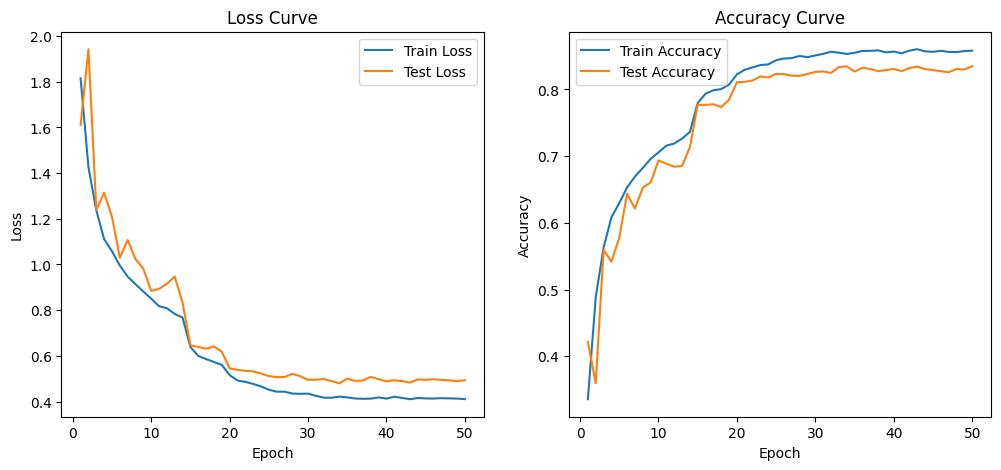

In [35]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

## Few shot learning - 1% of data used for training

In [44]:
NUM_WORKERS=2
BATCH_SIZE=100


# A class, that creates two augmentations of the same picture
class ContrastiveTransformations:
    def __init__(self, base_transforms):
        self.base_transforms = base_transforms

    def __call__(self, x):
        # Using transformations two times, to gety two different versions
        q = self.base_transforms(x)
        k = self.base_transforms(x)
        return [q, k]


contrastive_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Contrastive learning dataset
train_contrastive_dataset = torchvision.datasets.CIFAR10(
    root='/content/',
    train=True,
    download=True,
    transform=ContrastiveTransformations(contrastive_transforms)
)

contrastive_dataloader = DataLoader(
    dataset=train_contrastive_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True,
    drop_last=True
)

In [45]:
class SimCLR(nn.Module):
    def __init__(self, base_encoder, projection_dim=128):
        super().__init__()
        self.encoder = base_encoder

        # downloading number of features from oryginal classifier
        num_features = self.encoder.classifier[-1].in_features


        self.encoder.classifier = nn.Sequential(
            nn.MaxPool2d(4),
            nn.Flatten()
        )

        self.projection_head = nn.Sequential(
            nn.Linear(num_features, num_features, bias=False),
            nn.ReLU(),
            nn.Linear(num_features, projection_dim, bias=False)
        )

    def forward(self, x):
        features = self.encoder(x)
        projections = self.projection_head(features)
        return projections


class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss()
        self.similarity_f = nn.CosineSimilarity(dim=2)

    def forward(self, z_i, z_j):
        batch_size = z_i.shape[0]
        z = torch.cat([z_i, z_j], dim=0)
        sim_matrix = self.similarity_f(z.unsqueeze(1), z.unsqueeze(0))
        sim_ij = torch.diag(sim_matrix, batch_size)
        sim_ji = torch.diag(sim_matrix, -batch_size)
        positive_samples = torch.cat([sim_ij, sim_ji], dim=0).reshape(2 * batch_size, 1)

        mask = (~torch.eye(2 * batch_size, 2 * batch_size, dtype=bool)).to(device)

        negative_samples = sim_matrix[mask].reshape(2 * batch_size, -1)
        logits = torch.cat([positive_samples, negative_samples], dim=1)
        logits /= self.temperature
        labels = torch.zeros(2 * batch_size).to(device).long()
        loss = self.criterion(logits, labels)
        return loss

Needed to make resnet version which can work as encoder foe simclr comparison

In [46]:
class ResNet18_SimCLR(nn.Module):
    def __init__(self, num_classes=10, return_features=False):
        super().__init__()
        self.return_features = return_features  # <-- NEW

        self.initial_conv = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(64, 64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        layers.append(BasicBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn(self.initial_conv(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        features = torch.flatten(x, 1)   # <-- 512-dim embedding

        if self.return_features:
            return features              # <-- encoder mode

        logits = self.fc(features)       # <-- classifier mode
        return logits


In [47]:
PRETRAIN_EPOCHS = 100 #pretraining should have a lot of epochs(in paper 1000 epochs were used)
PRETRAIN_LR = 3e-4 #lower step should be used in pretraining than in standard learning
WEIGHT_DECAY = 1e-4 #as well as lower weight decay

base_encoder = ResNet18_SimCLR(return_features=True)
pretrain_model = SimCLR(base_encoder=base_encoder).to(device)

pretrain_loss_fn = NTXentLoss()
pretrain_optimizer = torch.optim.AdamW(pretrain_model.parameters(), lr=PRETRAIN_LR, weight_decay=WEIGHT_DECAY)

ENCODER_SAVE_PATH = 'simclr_resnet18_encoder.pth'

print("Pre-training SimCLR method resnet18 model")
for epoch in tqdm(range(PRETRAIN_EPOCHS)):
    pretrain_model.train()
    total_loss = 0
    for batch in contrastive_dataloader:
        images, _ = batch
        images_i, images_j = images[0].to(device), images[1].to(device)

        # forwards propatgation
        proj_i = pretrain_model(images_i)
        proj_j = pretrain_model(images_j)

        loss = pretrain_loss_fn(proj_i, proj_j)
        total_loss += loss.item()

        # backwards propagation
        pretrain_optimizer.zero_grad()
        loss.backward()
        pretrain_optimizer.step()

    avg_loss = total_loss / len(contrastive_dataloader)
    print(f"Pre-train Epoch: {epoch+1:03d}/{PRETRAIN_EPOCHS} | Loss: {avg_loss:.4f}")

# saving encoder weigths
torch.save(pretrain_model.encoder.state_dict(), ENCODER_SAVE_PATH)
print(f"\nZakończono pre-training. Wagi enkodera zapisane w: {ENCODER_SAVE_PATH}")

AttributeError: 'ResNet18_SimCLR' object has no attribute 'classifier'